In [139]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import joblib
import os

# Scikit-learn imports
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, 
                               BaggingClassifier, AdaBoostClassifier, 
                               GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [140]:
# Set the base data path
data_path = Path("data set")

# Load the three CSV files
print("Loading CSV files...")
accidents_df = pd.read_csv(data_path / "Accidents_2018.csv")
casualties_df = pd.read_csv(data_path / "Casualties_2018.csv")
vehicles_df = pd.read_csv(data_path / "Vehicles_2018.csv")

print(f"Accidents dataset shape: {accidents_df.shape}")
print(f"Casualties dataset shape: {casualties_df.shape}")
print(f"Vehicles dataset shape: {vehicles_df.shape}")


Loading CSV files...
Accidents dataset shape: (122635, 32)
Casualties dataset shape: (160597, 16)
Vehicles dataset shape: (226409, 23)


In [141]:
accidents_df.head()

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,0,0,4,1,1,0,0,1,1,E01000854
1,2018010080973,542020.0,184290.0,0.046471,51.539651,1,3,1,1,01/01/2018,...,0,0,4,1,1,0,0,1,1,E01003531
2,2018010080974,531720.0,182910.0,-0.102474,51.529746,1,3,2,1,01/01/2018,...,0,5,4,1,1,0,0,1,1,E01002723
3,2018010080981,541450.0,183220.0,0.037828,51.530179,1,2,2,1,01/01/2018,...,0,5,4,2,2,0,0,1,1,E01003492
4,2018010080982,543580.0,176500.0,0.065781,51.469258,1,2,2,2,01/01/2018,...,0,0,4,1,2,0,0,1,1,E01001682


In [142]:
print("Accidents Dataset columns:", accidents_df.columns.tolist())

Accidents Dataset columns: ['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', '2nd_Road_Class', '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location']


In [143]:
# Create aggregations for Casualties
casualties_agg = casualties_df.groupby('Accident_Index').agg({
    'Casualty_Reference': 'count',  # Number of casualties
    'Casualty_Severity': 'mean',    # Average severity
    'Age_of_Casualty': 'mean',      # Average age
    'Sex_of_Casualty': lambda x: (x == 1).sum(),  # Count of male casualties
}).rename(columns={
    'Casualty_Reference': 'Total_Casualties',
    'Casualty_Severity': 'Avg_Casualty_Severity',
    'Age_of_Casualty': 'Avg_Casualty_Age',
    'Sex_of_Casualty': 'Male_Casualties'
})

print("Casualties aggregation shape:", casualties_agg.shape)


Casualties aggregation shape: (122635, 4)


In [144]:
# Create aggregations for Vehicles
vehicles_agg = vehicles_df.groupby('Accident_Index').agg({
    'Vehicle_Reference': 'count',  # Number of vehicles
    'Age_of_Driver': 'mean',       # Average driver age
    'Sex_of_Driver': lambda x: (x == 1).sum(),  # Count of male drivers
}).rename(columns={
    'Vehicle_Reference': 'Total_Vehicles',
    'Age_of_Driver': 'Avg_Driver_Age',
    'Sex_of_Driver': 'Male_Drivers'
})

print("Vehicles aggregation shape:", vehicles_agg.shape)


Vehicles aggregation shape: (122635, 3)


In [145]:

# Merge all dataframes
df = accidents_df.copy()
df = df.merge(casualties_agg, left_on='Accident_Index', right_index=True, how='left')
df = df.merge(vehicles_agg, left_on='Accident_Index', right_index=True, how='left')

In [146]:
df = df.drop_duplicates(subset=['Accident_Index'])

In [147]:
print(f"\nMerged dataset shape: {df.shape}")



Merged dataset shape: (122635, 39)


In [148]:
print(f"Total columns: {len(df.columns)}")


Total columns: 39


In [149]:
print(f"\nFirst few rows of merged data:")
df.head()



First few rows of merged data:


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Total_Casualties,Avg_Casualty_Severity,Avg_Casualty_Age,Male_Casualties,Total_Vehicles,Avg_Driver_Age,Male_Drivers
0,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,1,1,E01000854,NaN,NaN,NaN,NaN,2.0,40.0,2.0
1,2018010080973,542020.0,184290.0,0.046471,51.539651,1,3,1,1,01/01/2018,...,1,1,E01003531,NaN,NaN,NaN,NaN,1.0,-1.0,0.0
2,2018010080974,531720.0,182910.0,-0.102474,51.529746,1,3,2,1,01/01/2018,...,1,1,E01002723,NaN,NaN,NaN,NaN,2.0,30.5,2.0
3,2018010080981,541450.0,183220.0,0.037828,51.530179,1,2,2,1,01/01/2018,...,1,1,E01003492,NaN,NaN,NaN,NaN,2.0,28.5,2.0
4,2018010080982,543580.0,176500.0,0.065781,51.469258,1,2,2,2,01/01/2018,...,1,1,E01001682,NaN,NaN,NaN,NaN,2.0,49.0,2.0


In [150]:
print(f"\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122635 entries, 0 to 122634
Data columns (total 39 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Accident_Index                               122635 non-null  object 
 1   Location_Easting_OSGR                        122580 non-null  float64
 2   Location_Northing_OSGR                       122580 non-null  float64
 3   Longitude                                    122580 non-null  float64
 4   Latitude                                     122580 non-null  float64
 5   Police_Force                                 122635 non-null  int64  
 6   Accident_Severity                            122635 non-null  int64  
 7   Number_of_Vehicles                           122635 non-null  int64  
 8   Number_of_Casualties                         122635 non-null  int64  
 9   Date                                        

In [151]:
df.isna().sum().sort_values(ascending=0)

Avg_Casualty_Age                               16384
Avg_Casualty_Severity                          16384
Total_Casualties                               16384
Male_Casualties                                16384
LSOA_of_Accident_Location                       6445
Avg_Driver_Age                                  1847
Male_Drivers                                    1847
Total_Vehicles                                  1847
Longitude                                         55
Location_Easting_OSGR                             55
Location_Northing_OSGR                            55
Latitude                                          55
Time                                              13
Accident_Index                                     0
Police_Force                                       0
Accident_Severity                                  0
Number_of_Vehicles                                 0
Date                                               0
Number_of_Casualties                          

In [152]:
drop_columns = [
    'Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
    'Longitude', 'Latitude', 'LSOA_of_Accident_Location',  
    'Date', 'Time', 
    'Local_Authority_(District)', 'Local_Authority_(Highway)', 
    '1st_Road_Number', '2nd_Road_Number' 
]

droped_columns = [col for col in drop_columns if col in df.columns]

df_clean = df.drop(columns=droped_columns)

print(f"Removed columns: {droped_columns}")
print(f"Dataset shape after column removal: {df_clean.shape}")
print(f"Remaining columns: {df_clean.columns.tolist()}")

Removed columns: ['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'LSOA_of_Accident_Location', 'Date', 'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', '1st_Road_Number', '2nd_Road_Number']
Dataset shape after column removal: (122635, 27)
Remaining columns: ['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', '2nd_Road_Class', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Total_Casualties', 'Avg_Casualty_Severity', 'Avg_Casualty_Age', 'Male_Casualties', 'Total_Vehicles', 'Avg_Driver_Age', 'Male_Drivers']


In [153]:
print("Missing values analysis:")
missing_data = df_clean.isnull().sum()
missing_percent = (missing_data / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_df)


Missing values analysis:
                   Column  Missing_Count  Missing_Percentage
20       Total_Casualties          16384           13.359971
21  Avg_Casualty_Severity          16384           13.359971
22       Avg_Casualty_Age          16384           13.359971
23        Male_Casualties          16384           13.359971
24         Total_Vehicles           1847            1.506095
25         Avg_Driver_Age           1847            1.506095
26           Male_Drivers           1847            1.506095


In [154]:
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            # Fill with median for numerical columns
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            # Fill with mode for categorical, or a placeholder if mode doesn't exist
            try:
                df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            except:
                df_clean[col].fillna(-1, inplace=True)

print(f"Total missing values: {df_clean.isnull().sum().sum()}")

Total missing values: 0


In [155]:
target_col = 'Accident_Severity'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Features shape: {X.shape}")
print(f"\nFeature columns ({len(X.columns)}): {X.columns.tolist()}")


Features shape: (122635, 26)

Feature columns (26): ['Police_Force', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', '2nd_Road_Class', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Total_Casualties', 'Avg_Casualty_Severity', 'Avg_Casualty_Age', 'Male_Casualties', 'Total_Vehicles', 'Avg_Driver_Age', 'Male_Drivers']


In [156]:
print(f"Target shape: {y.shape}")
print(f"\nTarget variable statistics:")
print(y.describe())
print(f"\nTarget class distribution:")
print(y.value_counts().sort_index())


Target shape: (122635,)

Target variable statistics:
count    122635.000000
mean          2.783855
std           0.443486
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: Accident_Severity, dtype: float64

Target class distribution:
Accident_Severity
1     1671
2    23165
3    97799
Name: count, dtype: int64


In [157]:
print(f"\nTarget variable statistics:")
y.describe()



Target variable statistics:


count    122635.000000
mean          2.783855
std           0.443486
min           1.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: Accident_Severity, dtype: float64

In [158]:
print(f"\nTarget class distribution:")
y.value_counts().sort_index()



Target class distribution:


Accident_Severity
1     1671
2    23165
3    97799
Name: count, dtype: int64

In [159]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")


Categorical columns: []


In [160]:
label_encoders = {}

# Encode categorical variables
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    
# Ensure all columns are numeric
X = X.astype('float64')

In [161]:
print(f"Data types after encoding:")
X.dtypes

Data types after encoding:


Police_Force                                   float64
Number_of_Vehicles                             float64
Number_of_Casualties                           float64
Day_of_Week                                    float64
1st_Road_Class                                 float64
Road_Type                                      float64
Speed_limit                                    float64
Junction_Detail                                float64
Junction_Control                               float64
2nd_Road_Class                                 float64
Pedestrian_Crossing-Human_Control              float64
Pedestrian_Crossing-Physical_Facilities        float64
Light_Conditions                               float64
Weather_Conditions                             float64
Road_Surface_Conditions                        float64
Special_Conditions_at_Site                     float64
Carriageway_Hazards                            float64
Urban_or_Rural_Area                            float64
Did_Police

In [162]:
print(f"Final feature matrix shape: {X.shape}")


Final feature matrix shape: (122635, 26)


In [163]:
X.head()

,Police_Force,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,1st_Road_Class,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Class,...,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Total_Casualties,Avg_Casualty_Severity,Avg_Casualty_Age,Male_Casualties,Total_Vehicles,Avg_Driver_Age,Male_Drivers
0,1.0,2.0,2.0,2.0,3.0,3.0,30.0,0.0,-1.0,-1.0,...,0.0,1.0,1.0,1.0,3.0,35.0,1.0,2.0,40.0,2.0
1,1.0,1.0,1.0,2.0,4.0,6.0,30.0,2.0,4.0,6.0,...,0.0,1.0,1.0,1.0,3.0,35.0,1.0,1.0,-1.0,0.0
2,1.0,2.0,1.0,2.0,3.0,6.0,20.0,6.0,4.0,5.0,...,0.0,1.0,1.0,1.0,3.0,35.0,1.0,2.0,30.5,2.0
3,1.0,2.0,1.0,2.0,4.0,3.0,30.0,7.0,2.0,3.0,...,0.0,1.0,1.0,1.0,3.0,35.0,1.0,2.0,28.5,2.0
4,1.0,2.0,2.0,2.0,3.0,6.0,30.0,0.0,-1.0,-1.0,...,0.0,1.0,1.0,1.0,3.0,35.0,1.0,2.0,49.0,2.0


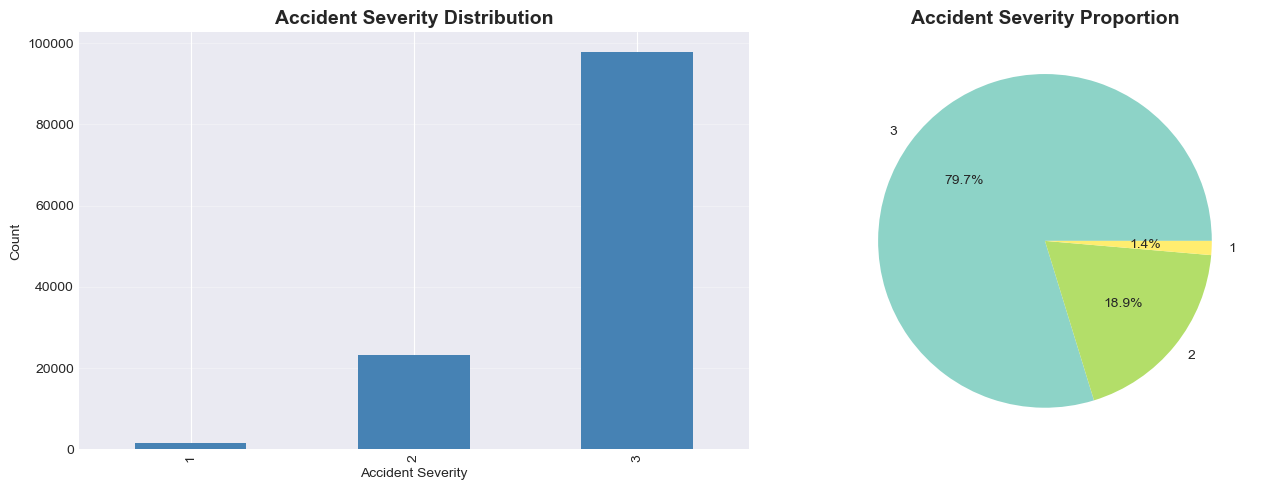

Target class distribution:
Accident_Severity
1     1671
2    23165
3    97799
Name: count, dtype: int64


In [164]:

# Plot 1: Target Variable Distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
y.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Accident Severity Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Accident Severity')
ax[0].set_ylabel('Count')
ax[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(y.unique())))
y.value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=colors)
ax[1].set_title('Accident Severity Proportion', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Target class distribution:\n{y.value_counts().sort_index()}")

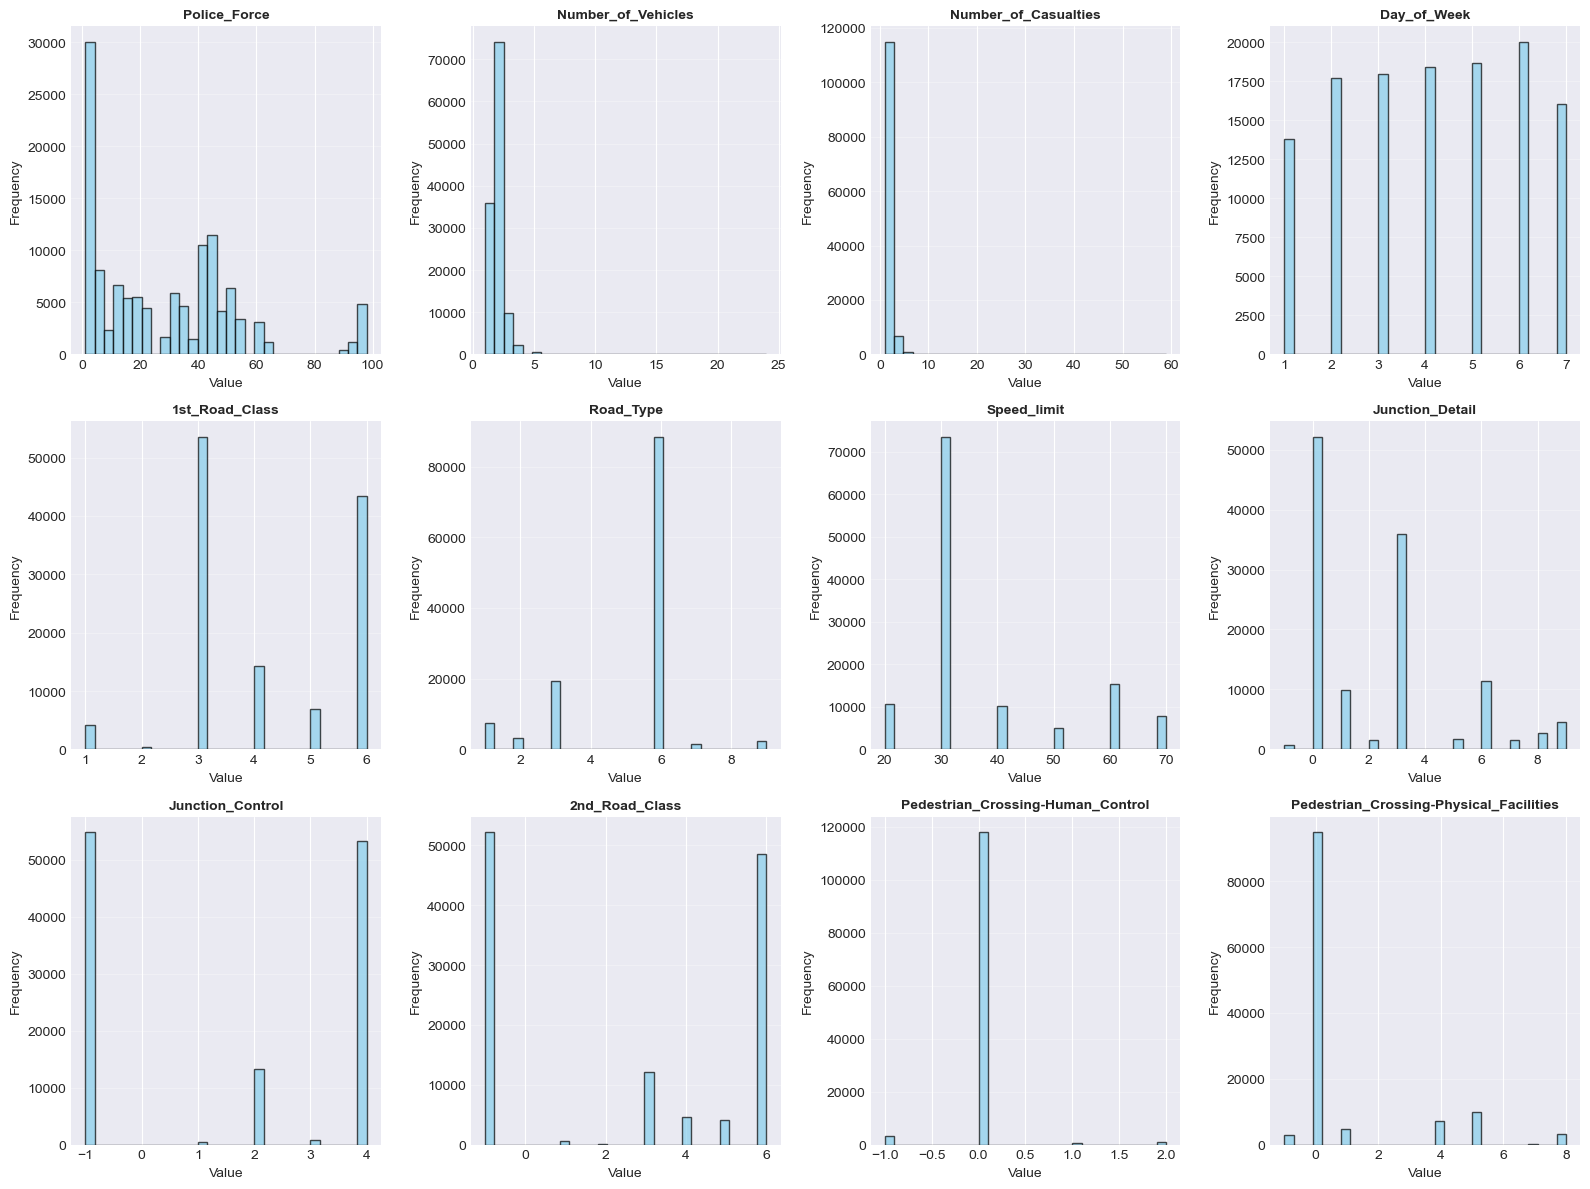

Feature distributions visualized for top 12 features


In [165]:
top_features = X.columns[:12].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(top_features):
    axes[idx].hist(X[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Feature distributions visualized for top 12 features")

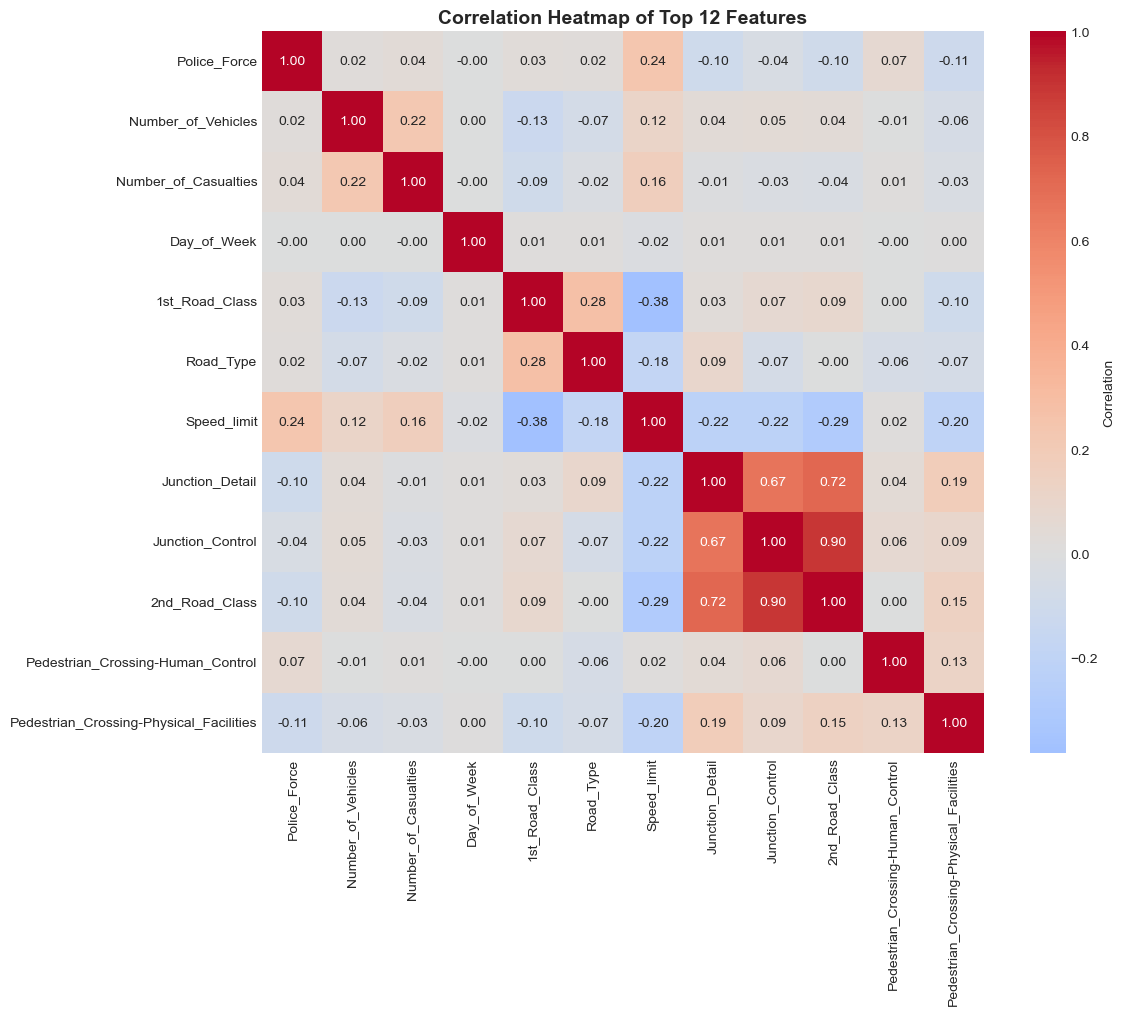

Correlation heatmap displayed


In [166]:
correlation_matrix = X[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap of Top 12 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation heatmap displayed")

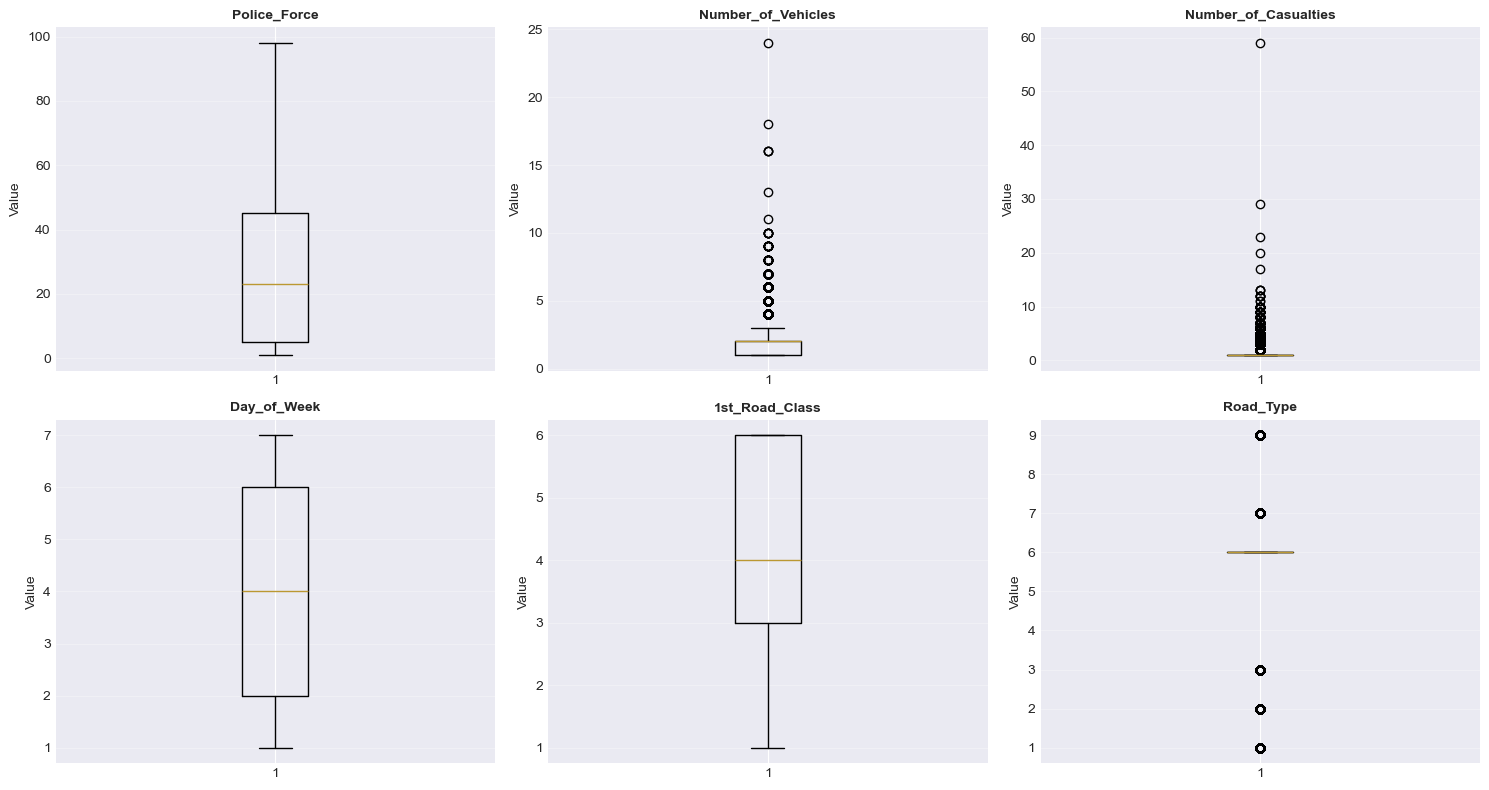

Box plots displayed for outlier detection


In [167]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(top_features[:6]):
    axes[idx].boxplot(X[col], vert=True)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Box plots displayed for outlier detection")

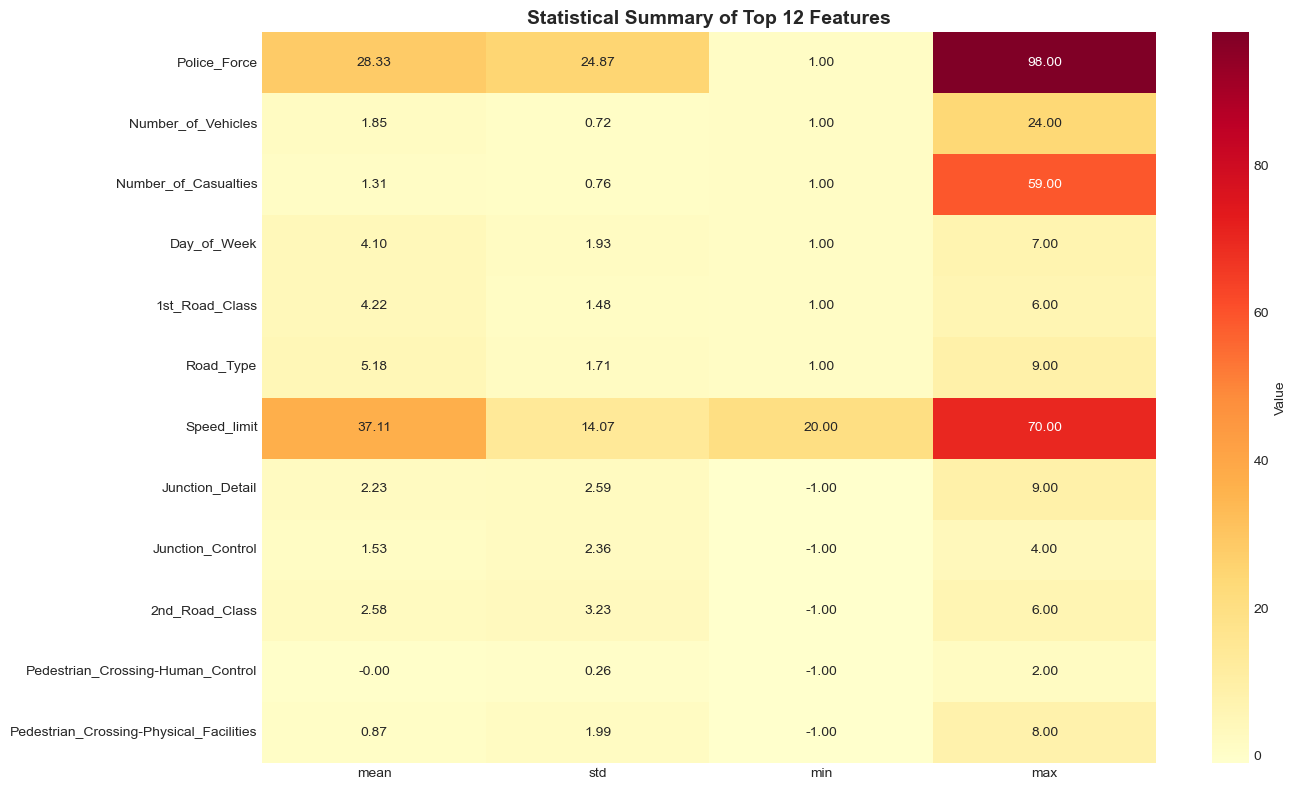

In [168]:
# Plot 5: Feature statistics summary
fig, ax = plt.subplots(figsize=(14, 8))

# Get basic statistics
stats_summary = X[top_features].describe().T

# Create a heatmap of statistics
sns.heatmap(stats_summary[['mean', 'std', 'min', 'max']], annot=True, fmt='.2f', 
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Value'})
ax.set_title('Statistical Summary of Top 12 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [169]:

print("Feature statistics summary:\n")
print(X[top_features].describe())

Feature statistics summary:

        Police_Force  Number_of_Vehicles  Number_of_Casualties    Day_of_Week  \
count  122635.000000       122635.000000         122635.000000  122635.000000   
mean       28.329947            1.846202              1.309553       4.098463   
std        24.869499            0.721339              0.763476       1.926830   
min         1.000000            1.000000              1.000000       1.000000   
25%         5.000000            1.000000              1.000000       2.000000   
50%        23.000000            2.000000              1.000000       4.000000   
75%        45.000000            2.000000              1.000000       6.000000   
max        98.000000           24.000000             59.000000       7.000000   

       1st_Road_Class      Road_Type    Speed_limit  Junction_Detail  \
count   122635.000000  122635.000000  122635.000000    122635.000000   
mean         4.219016       5.175896      37.105557         2.227415   
std          1.476726    

In [170]:
# Method 1: Feature importance from Random Forest
print("Method 1: Random Forest Feature Importance")
print("=" * 70)

# Train a quick Random Forest to get feature importances
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_quick.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
print(feature_importances.head(20))



Method 1: Random Forest Feature Importance

Top 20 Most Important Features:
                                        Feature  Importance
20                        Avg_Casualty_Severity    0.909428
21                             Avg_Casualty_Age    0.012407
0                                  Police_Force    0.009491
18  Did_Police_Officer_Attend_Scene_of_Accident    0.008121
24                               Avg_Driver_Age    0.008086
22                              Male_Casualties    0.006247
1                            Number_of_Vehicles    0.005697
23                               Total_Vehicles    0.003875
3                                   Day_of_Week    0.003446
6                                   Speed_limit    0.003340
2                          Number_of_Casualties    0.002707
17                          Urban_or_Rural_Area    0.002599
19                             Total_Casualties    0.002419
4                                1st_Road_Class    0.002379
25                      

In [171]:
# Select top N features
N_TOP_FEATURES = 20
top_features_selected = feature_importances.head(N_TOP_FEATURES)['Feature'].tolist()
print(f"Selected top {N_TOP_FEATURES} features for modeling:")
top_features_selected

Selected top 20 features for modeling:


['Avg_Casualty_Severity',
 'Avg_Casualty_Age',
 'Police_Force',
 'Did_Police_Officer_Attend_Scene_of_Accident',
 'Avg_Driver_Age',
 'Male_Casualties',
 'Number_of_Vehicles',
 'Total_Vehicles',
 'Day_of_Week',
 'Speed_limit',
 'Number_of_Casualties',
 'Urban_or_Rural_Area',
 'Total_Casualties',
 '1st_Road_Class',
 'Male_Drivers',
 'Light_Conditions',
 'Junction_Detail',
 'Road_Type',
 'Pedestrian_Crossing-Physical_Facilities',
 'Weather_Conditions']

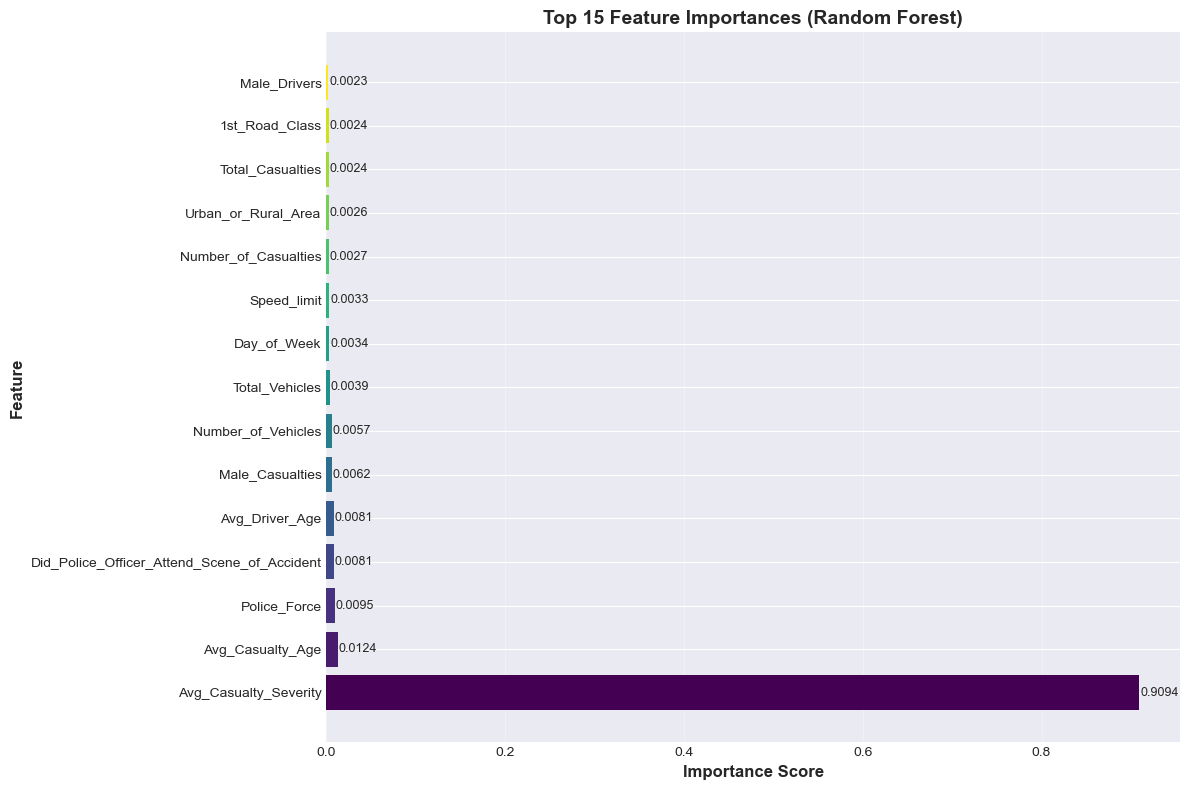

In [172]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))

top_15_features = feature_importances.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_15_features)))

ax.barh(range(len(top_15_features)), top_15_features['Importance'], color=colors)
ax.set_yticks(range(len(top_15_features)))
ax.set_yticklabels(top_15_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_15_features['Importance']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [173]:
# Method 2: SelectKBest with f_classif
print("\nMethod 2: SelectKBest Statistical Test")
print("=" * 70)

# Use SelectKBest to identify most important features
selector = SelectKBest(score_func=f_classif, k=N_TOP_FEATURES)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_indices = selector.get_support(indices=True)
selectkbest_features = X.columns[selected_indices].tolist()

# Get scores
selector_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(f"\nTop features by SelectKBest score:")
print(selector_scores.head(15))


Method 2: SelectKBest Statistical Test

Top features by SelectKBest score:
                                        Feature          Score
20                        Avg_Casualty_Severity  290092.032846
18  Did_Police_Officer_Attend_Scene_of_Accident    1150.603823
22                              Male_Casualties     901.966397
6                                   Speed_limit     592.596165
17                          Urban_or_Rural_Area     590.391151
24                               Avg_Driver_Age     505.198480
21                             Avg_Casualty_Age     477.662445
19                             Total_Casualties     423.739474
2                          Number_of_Casualties     368.900544
1                            Number_of_Vehicles     291.240984
23                               Total_Vehicles     290.714934
9                                2nd_Road_Class     213.135170
12                             Light_Conditions     197.273432
0                                  Police_

In [174]:
combined_features = set(top_features_selected) & set(selector_scores.head(N_TOP_FEATURES)['Feature'].tolist())
if len(combined_features) < N_TOP_FEATURES:
    # If intersection is too small, merge and take top N
    all_top_features = list(set(top_features_selected) | set(selector_scores.head(N_TOP_FEATURES)['Feature'].tolist()))
    combined_features = all_top_features[:N_TOP_FEATURES]

final_features = sorted(list(combined_features))

print(f"\nFinal selected features ({len(final_features)} features):")
print(final_features)

# Create final feature dataset
X_final = X[final_features].copy()

print(f"\nFinal dataset shape: {X_final.shape}")
print(f"Original dataset shape: {X.shape}")
print(f"Feature reduction: {X.shape[1]} → {X_final.shape[1]} ({100 * (1 - X_final.shape[1] / X.shape[1]):.1f}% reduction)")


Final selected features (20 features):
['1st_Road_Class', 'Avg_Casualty_Age', 'Avg_Casualty_Severity', 'Avg_Driver_Age', 'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Light_Conditions', 'Male_Casualties', 'Male_Drivers', 'Number_of_Casualties', 'Number_of_Vehicles', 'Pedestrian_Crossing-Physical_Facilities', 'Police_Force', 'Road_Type', 'Speed_limit', 'Total_Casualties', 'Total_Vehicles', 'Urban_or_Rural_Area', 'Weather_Conditions']

Final dataset shape: (122635, 20)
Original dataset shape: (122635, 26)
Feature reduction: 26 → 20 (23.1% reduction)


In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [176]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [177]:
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
print(f"Feature set: {X_train_scaled.shape[1]} features")


Training set size: (98108, 20)
Test set size: (24527, 20)
Feature set: 20 features


In [178]:
print(f"\nClass distribution in training set:")
pd.Series(y_train).value_counts().sort_index()


Class distribution in training set:


Accident_Severity
1     1337
2    18532
3    78239
Name: count, dtype: int64

In [179]:
# Define classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=20),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=20),
    'Bagging': BaggingClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=10),
    'HistGradient Boosting': HistGradientBoostingClassifier(max_iter=200, random_state=42)
}

# Train and evaluate models
results = {}
predictions = {}

print("Training models...")
print("=" * 70)

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    # Train model
    clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = clf.predict(X_train_scaled)
    y_pred_test = clf.predict(X_test_scaled)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    # Store results
    results[name] = {
        'Model': clf,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Predictions': y_pred_test
    }
    
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy:  {test_accuracy:.4f}")
    
print("\nModel training completed!")

Training models...

Training Random Forest...
  Train Accuracy: 0.9835
  Test Accuracy:  0.9770

Training Extra Trees...
  Train Accuracy: 0.9806
  Test Accuracy:  0.9768

Training Bagging...
  Train Accuracy: 0.9995
  Test Accuracy:  0.9752

Training AdaBoost...
  Train Accuracy: 0.9746
  Test Accuracy:  0.9745

Training Gradient Boosting...
  Train Accuracy: 0.9981
  Test Accuracy:  0.9750

Training HistGradient Boosting...
  Train Accuracy: 0.9792
  Test Accuracy:  0.9768

Model training completed!


In [180]:
# Display detailed classification reports
print("\nDetailed Classification Reports")
print("=" * 70)

for name, result in results.items():
    print(f"\n{name}:")
    print("-" * 70)
    print(classification_report(y_test, result['Predictions'], digits=4))


Detailed Classification Reports

Random Forest:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           1     0.9961    0.7665    0.8663       334
           2     0.9836    0.8960    0.9378      4633
           3     0.9754    0.9998    0.9875     19560

    accuracy                         0.9770     24527
   macro avg     0.9851    0.8874    0.9305     24527
weighted avg     0.9772    0.9770    0.9764     24527


Extra Trees:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           1     0.9885    0.7695    0.8653       334
           2     0.9845    0.8940    0.9371      4633
           3     0.9751    1.0000    0.9874     19560

    accuracy                         0.9768     24527
   macro avg     0.9827    0.8878    0.9299     24527
weighted avg     0.9770    0.9768    0.9762     24527


Bagging:
-----------------------

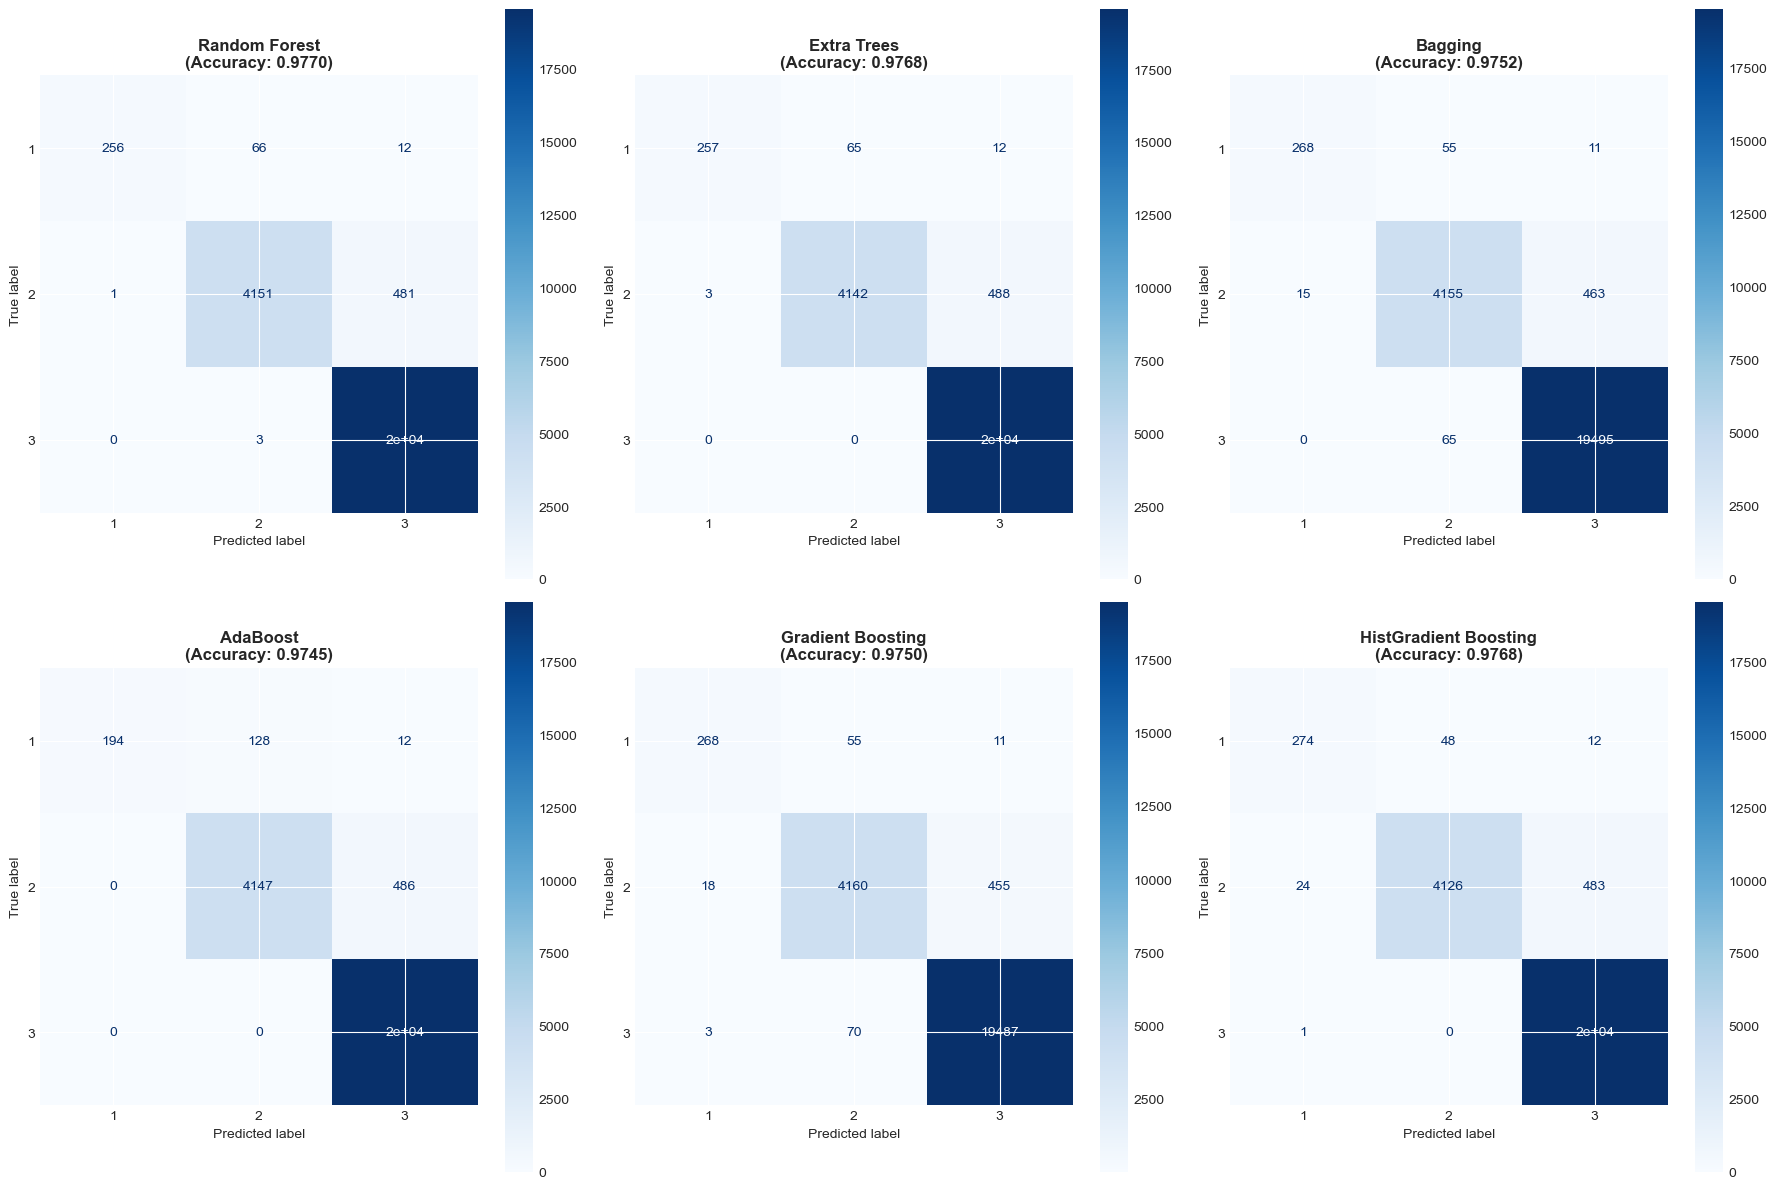

Confusion matrices displayed for all models


In [181]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['Predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\n(Accuracy: {result["Test_Accuracy"]:.4f})', 
                        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Confusion matrices displayed for all models")

In [182]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Train Accuracy': [results[m]['Train_Accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['Test_Accuracy'] for m in results.keys()]
})

# Sort by test accuracy
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("Model Performance Comparison")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['Model']
best_accuracy = comparison_df.iloc[0]['Test Accuracy']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f}")
print(f"{'='*70}")

Model Performance Comparison
                Model  Train Accuracy  Test Accuracy  Rank
        Random Forest        0.983549       0.977046     1
          Extra Trees        0.980562       0.976842     2
HistGradient Boosting        0.979176       0.976842     3
              Bagging        0.999511       0.975170     4
    Gradient Boosting        0.998063       0.975048     5
             AdaBoost        0.974610       0.974477     6

BEST MODEL: Random Forest
Test Accuracy: 0.9770


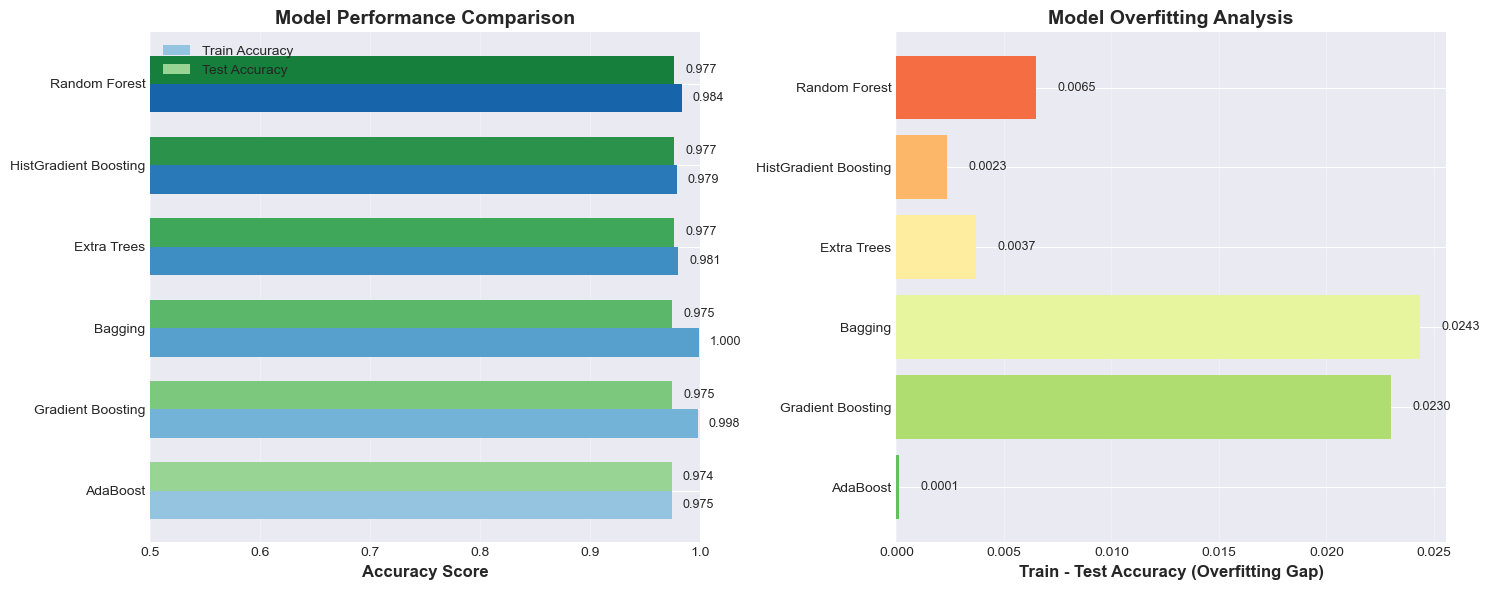

Model comparison visualizations displayed


In [183]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot comparison
comparison_sorted = comparison_df.sort_values('Test Accuracy', ascending=True)
colors_train = plt.cm.Blues(np.linspace(0.4, 0.8, len(comparison_sorted)))
colors_test = plt.cm.Greens(np.linspace(0.4, 0.8, len(comparison_sorted)))

x_pos = np.arange(len(comparison_sorted))
width = 0.35

axes[0].barh(x_pos - width/2, comparison_sorted['Train Accuracy'], width, 
             label='Train Accuracy', color=colors_train)
axes[0].barh(x_pos + width/2, comparison_sorted['Test Accuracy'], width, 
             label='Test Accuracy', color=colors_test)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(comparison_sorted['Model'])
axes[0].set_xlabel('Accuracy Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0.5, 1.0)

# Add value labels
for i, (train, test) in enumerate(zip(comparison_sorted['Train Accuracy'], 
                                       comparison_sorted['Test Accuracy'])):
    axes[0].text(train + 0.01, i - width/2, f'{train:.3f}', va='center', fontsize=9)
    axes[0].text(test + 0.01, i + width/2, f'{test:.3f}', va='center', fontsize=9)

# Accuracy difference plot
comparison_sorted['Overfitting'] = comparison_sorted['Train Accuracy'] - comparison_sorted['Test Accuracy']
colors_overfit = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(comparison_sorted)))

axes[1].barh(range(len(comparison_sorted)), comparison_sorted['Overfitting'], 
             color=colors_overfit)
axes[1].set_yticks(range(len(comparison_sorted)))
axes[1].set_yticklabels(comparison_sorted['Model'])
axes[1].set_xlabel('Train - Test Accuracy (Overfitting Gap)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(comparison_sorted['Overfitting']):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Model comparison visualizations displayed")

In [184]:
# Create a models directory if it doesn't exist
models_dir = Path("models2_final_note")
models_dir.mkdir(exist_ok=True)

print(f"Saving models to: {models_dir.resolve()}")
print("=" * 70)

# Save the best model
model_filename = models_dir / f"best_model_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(best_model, model_filename)
print(f"✓ Best model saved: {model_filename}")

# Save the scaler
scaler_filename = models_dir / "scaler.pkl"
joblib.dump(scaler, scaler_filename)
print(f"✓ Feature scaler saved: {scaler_filename}")

# Save the label encoders
encoders_filename = models_dir / "label_encoders.pkl"
joblib.dump(label_encoders, encoders_filename)
print(f"✓ Label encoders saved: {encoders_filename}")

# Save feature names for deployment
feature_names_filename = models_dir / "feature_names.pkl"
joblib.dump(final_features, feature_names_filename)
print(f"✓ Feature names saved: {feature_names_filename}")

print("=" * 70)

Saving models to: D:\nti crativa\test\models2_final_note
✓ Best model saved: models2_final_note\best_model_Random_Forest.pkl
✓ Feature scaler saved: models2_final_note\scaler.pkl
✓ Label encoders saved: models2_final_note\label_encoders.pkl
✓ Feature names saved: models2_final_note\feature_names.pkl


In [185]:
# Create a deployment summary report
summary_report = f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                   ACCIDENT SEVERITY PREDICTION - FINAL REPORT                 ║
╚═══════════════════════════════════════════════════════════════════════════════╝

PROJECT SUMMARY
───────────────────────────────────────────────────────────────────────────────
Target Variable: Accident_Severity
Problem Type: Multi-class Classification
Dataset Size: {len(df)} records
Training Set: {len(X_train)} records
Test Set: {len(X_test)} records

DATA PROCESSING
───────────────────────────────────────────────────────────────────────────────
Original Features: {X.shape[1]}
Selected Features: {X_final.shape[1]}
Feature Reduction: {100 * (1 - X_final.shape[1] / X.shape[1]):.1f}%

Selected Features: {', '.join(final_features)}

BEST MODEL PERFORMANCE
───────────────────────────────────────────────────────────────────────────────
Model: {best_model_name}
Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)
Train Accuracy: {comparison_df.iloc[0]['Train Accuracy']:.4f}
Overfitting Gap: {comparison_df.iloc[0]['Train Accuracy'] - best_accuracy:.4f}

ALL MODELS RANKING
───────────────────────────────────────────────────────────────────────────────
{comparison_df[['Rank', 'Model', 'Test Accuracy']].to_string(index=False)}

DEPLOYMENT ARTIFACTS
───────────────────────────────────────────────────────────────────────────────
✓ Model File: {model_filename.name}
✓ Feature Scaler: {scaler_filename.name}
✓ Label Encoders: {encoders_filename.name}
✓ Feature Names: {feature_names_filename.name}

USAGE INSTRUCTIONS FOR DEPLOYMENT
───────────────────────────────────────────────────────────────────────────────
1. Load the model:
   model = joblib.load('models/best_model_{best_model_name.replace(' ', '_')}.pkl')
   scaler = joblib.load('models/scaler.pkl')
   features = joblib.load('models/feature_names.pkl')

2. Prepare new data:
   - Ensure categorical variables are properly encoded
   - Use the same feature names as defined
   - Scale the features using the saved scaler

3. Make predictions:
   X_new_scaled = scaler.transform(X_new[features])
   predictions = model.predict(X_new_scaled)

TIMESTAMP: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
═══════════════════════════════════════════════════════════════════════════════
"""

print(summary_report)

# Save the report to a text file
report_filename = models_dir / "deployment_report.txt"
with open(report_filename, 'w') as f:
    f.write(summary_report)

print(f"\nDeployment report saved to: {report_filename}")


╔═══════════════════════════════════════════════════════════════════════════════╗
║                   ACCIDENT SEVERITY PREDICTION - FINAL REPORT                 ║
╚═══════════════════════════════════════════════════════════════════════════════╝

PROJECT SUMMARY
───────────────────────────────────────────────────────────────────────────────
Target Variable: Accident_Severity
Problem Type: Multi-class Classification
Dataset Size: 122635 records
Training Set: 98108 records
Test Set: 24527 records

DATA PROCESSING
───────────────────────────────────────────────────────────────────────────────
Original Features: 26
Selected Features: 20
Feature Reduction: 23.1%

Selected Features: 1st_Road_Class, Avg_Casualty_Age, Avg_Casualty_Severity, Avg_Driver_Age, Day_of_Week, Junction_Control, Junction_Detail, Light_Conditions, Male_Casualties, Male_Drivers, Number_of_Casualties, Number_of_Vehicles, Pedestrian_Crossing-Physical_Facilities, Police_Force, Road_Type, Speed_limit, Total_Casualties, Tota

In [186]:
# Test the saved model to ensure it can be loaded and used
print("\nVerifying Saved Model...")
print("=" * 70)

# Load the saved model
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
loaded_features = joblib.load(feature_names_filename)

# Make a prediction on test data
X_test_subset = X_test[loaded_features].values
X_test_scaled_new = loaded_scaler.transform(X_test_subset)
test_predictions = loaded_model.predict(X_test_scaled_new)

# Verify predictions match
verification_accuracy = accuracy_score(y_test, test_predictions)
print(f"✓ Model loaded successfully")
print(f"✓ Loaded model test accuracy: {verification_accuracy:.4f}")
print(f"✓ Predictions match original model: {np.array_equal(test_predictions, results[best_model_name]['Predictions'])}")
print("\nAll systems ready for deployment!")


Verifying Saved Model...
✓ Model loaded successfully
✓ Loaded model test accuracy: 0.9770
✓ Predictions match original model: True

All systems ready for deployment!
